# DATA 620 Assignment 2

For this first assingment we are going to plot a simple graph of my favorite nolan movies and see how the actors relate to the movies. 
The Nodes will be 9 of Nolans movies and the actors that appear in atleast 2 of them . Even though it has nodes of two types , its still a relatively simple subset 
The Edges show which actor was in which movie. 

In [1]:
import sys
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

## Loading 


In [2]:
df = pd.read_csv("nolan_films_cast.csv")

print("Rows:", len(df))
df.head()

Rows: 42


,film,actor
0,Batman Begins,Christian Bale
1,Batman Begins,Michael Caine
2,Batman Begins,Gary Oldman
3,Batman Begins,Morgan Freeman
4,Batman Begins,Cillian Murphy


## Building graph
Each row of the CSV becomes one edge between a film and an actor.

In [3]:
G = nx.from_pandas_edgelist(df, source="film", target="actor")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 22
Edges: 42


## Plotting graph

We will use networkx to draw the graph. Red cirlces are films. Blue circles are actors,

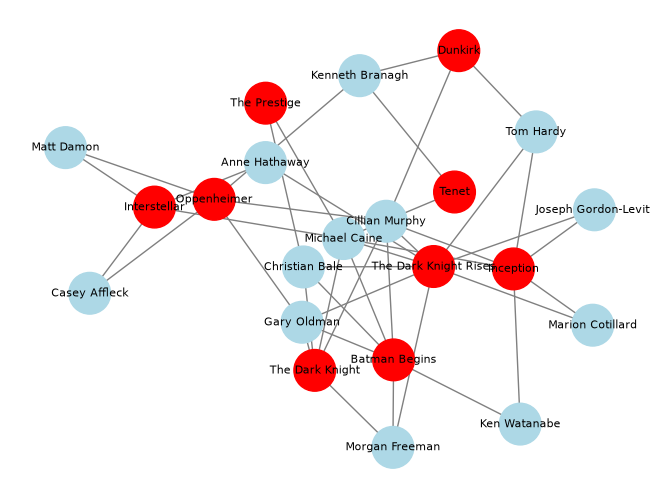

In [4]:
films = df["film"].unique()
colors = ["red" if node in films else "lightblue" for node in G]
pos = nx.spring_layout(G, k=0.6, seed=123)
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=900,
        font_size=8, edge_color="gray")
plt.show()

## Simple analysis : Sorting by most appearances

In [5]:
df["actor"].value_counts().head(5)

actor
Michael Caine     7
Cillian Murphy    6
Christian Bale    4
Gary Oldman       4
Morgan Freeman    3
Name: count, dtype: int64

## Next steps
It would possibly be to have movies on one side and actors on the other for better visibility

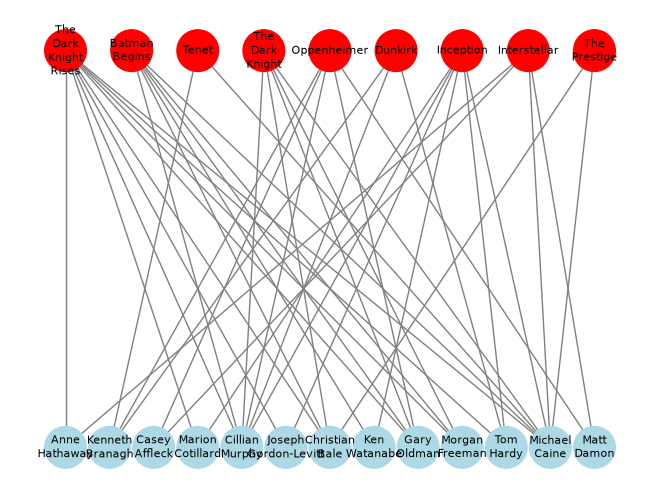

In [6]:
actors = df["actor"].unique()
pos = nx.bipartite_layout(G, actors, align="horizontal") 
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=900, font_size=8,
        edge_color="gray", labels={n: n.replace(" ", "\n") for n in G})
plt.show()